# How to Train a Neural Network to Detect Fraudulent Credit Card Transactions

## Imports

In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Data Loading and Exploration

In [2]:
# Import dataset as pandas df
# Ref: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
df = pd.read_csv("./data/creditcard.csv")

# calculate how much is fraudulent or not, and %
num_of_non_fraudulent_transactions = len(df[df["Class"] == 0])
num_of_fraudulent_transactions = len(df[df["Class"] == 1])
percentage_of_fraudulent_transactions = num_of_fraudulent_transactions / len(df) * 100

# print out some stats
print("Null values in dataset:", df.isnull().values.any())
print("Total transactions:", len(df))
print("Number of non-fraudulent transactions:", num_of_non_fraudulent_transactions)
print("Number of fraudulent transactions:", num_of_fraudulent_transactions)
print("Percentage of fraudulent transactions:", percentage_of_fraudulent_transactions)

Null values in dataset: False
Total transactions: 284807
Number of non-fraudulent transactions: 284315
Number of fraudulent transactions: 492
Percentage of fraudulent transactions: 0.1727485630620034


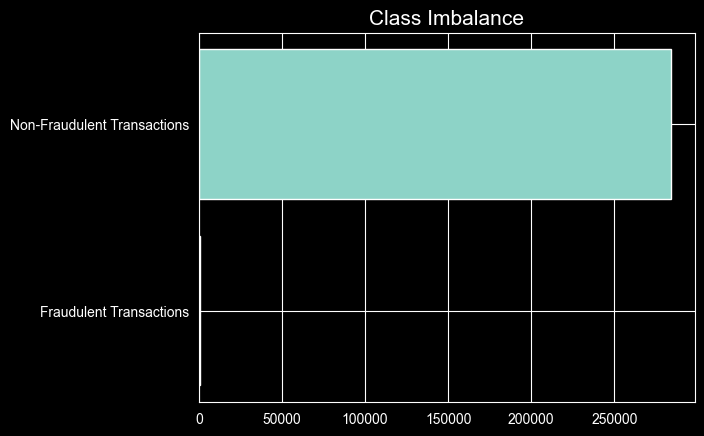

In [3]:
# display the class imbalance visually
x = np.array(["Fraudulent Transactions", "Non-Fraudulent Transactions"])
y = np.array([num_of_fraudulent_transactions, num_of_non_fraudulent_transactions])
plt.title('Class Imbalance', fontsize=15)
plt.barh(x,y)
plt.show()

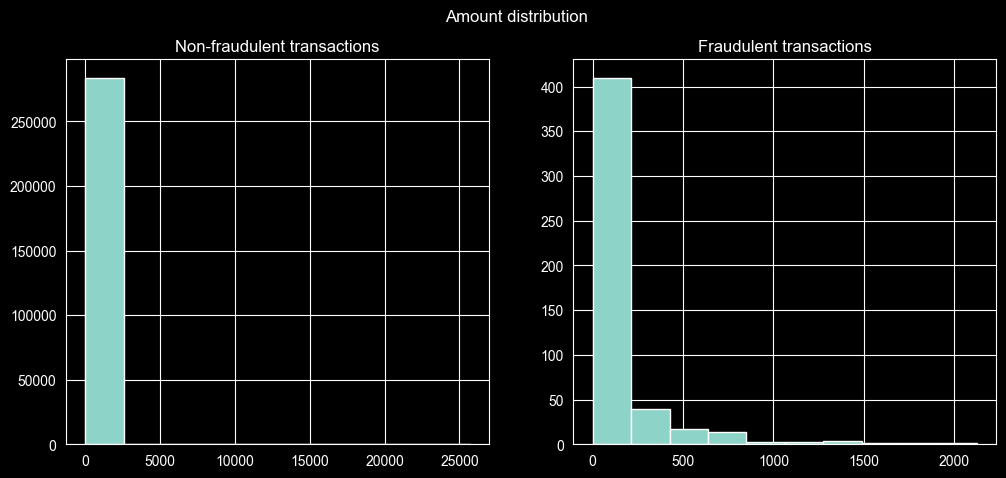

In [4]:
# for each class, display the amounts as a bar chart to show how the distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
data_1 = df[df["Class"] == 0].Amount
ax1.hist(data_1)
ax1.set_title("Non-fraudulent transactions")
fig.suptitle("Amount distribution")
data_2 = df[df["Class"] == 1].Amount
ax2.hist(data_2)
ax2.set_title("Fraudulent transactions")
plt.show()

## Preprocessing

In [5]:
# split data into features and labels, then into train and test sets
features = df.drop("Class", axis=1)
label = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.33, random_state=42)
scaler = StandardScaler()

# most features are already normalized, so only normalize amount (time is irrelevant, could drop, doesn't matter)
X_train[['Amount']] = scaler.fit_transform(X_train[['Amount']])
X_test[['Amount']] = scaler.transform(X_test[['Amount']])

In [6]:
# Use GPU if available (MPS for Apple Silicon, CUDA for NVIDIA, otherwise CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [7]:
# convert dataframes into tensors and move to device once upfront to avoid per-batch transfer overhead
X_train_tensor = torch.tensor(X_train.values).float().to(device)
X_test_tensor = torch.tensor(X_test.values).float().to(device)
y_train_tensor = torch.tensor(y_train.values).float().to(device)
y_test_tensor = torch.tensor(y_test.values).float().to(device)

In [55]:
# Larger batch size reduces number of batches per epoch (from ~1900 to ~47), cutting GPU kernel launch overhead
# Smoother gradients: Each update averages over more samples, so gradients are less noisy. This can make training more stable but also means the model gets fewer weight updates per epoch (47 vs 1,900).
# Class imbalance gets worse: With batch size 100, most batches had 0 fraud samples. With 4096, you'll get ~1-2 fraud samples per batch on average - still heavily dominated by non-fraud, but each update covers more data.
batch_size = 4096

# https://discuss.pytorch.org/t/what-do-tensordataset-and-dataloader-do/107017
# TensorDataset essentially zips together the features and the labels by matching indices so that they are synchronized when batching
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
validation_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader makes batching and shuffling easy when training, automatically batching the data from the tensors so memory can be used effectively
train_data_loader = torch.utils.data.DataLoader(train_dataset, batch_size)
validation_data_loader = torch.utils.data.DataLoader(validation_dataset, batch_size)

## Neural Network Model

### Loss Function

This function is used across all three configurations:

In [9]:
# Define loss function to be used in all configurations
# Ref: https://www.kaggle.com/code/rinabuoy/credit-card-fraud-detection-with-pytorch

def loss_batch(model, loss_function, xb, yb, opt=None):
    # Forward pass: get predictions, compute loss
    # Reshape yb to [batch_size, 1] to match model output shape
    loss = loss_function(model(xb), yb.view(-1, 1))

    # If optimiser provided, we're training (not validating)
    if opt is not None:
        loss.backward() # Compute gradients via backpropagation
        opt.step() # Update weights using gradients
        opt.zero_grad() # Clear gradients for next batch otherwise the next backward call would add to existing gradients instead of replacing

    # Return scalar loss and batch size
    return loss.item(), len(xb)

### Training Function

This function is used across all three configurations:

In [10]:
# Ref: https://www.kaggle.com/code/rinabuoy/credit-card-fraud-detection-with-pytorch

def train(epochs, model, loss_function, optimiser, train_data_loader, validation_data_loader):
    for epoch in range(epochs):
        # Set model to training mode
        model.train()

        # Process batches using vectorised operations
        for x_batch, y_batch in train_data_loader:
            # Process each training batch
            # optimiser is passed, so loss_batch will: compute loss, compute gradients, update weights, clear gradients
            loss_batch(model, loss_function, x_batch, y_batch, optimiser)


        # Validation phase
        # Set model to evaluation mode
        model.eval()

        # Disable gradient computation to reduce computation (good practice, wouldn't affect outcome regardless as gradients aren't computed on validation phase - no optimiser)
        with torch.no_grad():
            # For each validation batch, compute loss (no weight updates since opt=None)
            losses, nums = zip(
                *[loss_batch(model, loss_function, xb, yb) for xb, yb in validation_data_loader]
            )

        # Compute weighted average loss across all validation batches
        # Why weighted? Last batch might be smaller, so weight by batch size
        val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)

        print(epoch, val_loss)

### Unified Neural Network Class

This merged class is used across all configurations with a `use_sigmoid` parameter:
- `use_sigmoid=True` for Config 1 (BCELoss requires sigmoid output)
- `use_sigmoid=False` for Config 2 & 3 (BCEWithLogitsLoss and FocalLoss apply sigmoid internally)

In [34]:
# Ref: https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

# Define the Neural Network using PyTorch with one hidden layer with 128 nodes, one output node, and configurable input dimension (incase it changes)
class NeuralNetwork(nn.Module):
    def __init__(self, input_dimension, hidden_layer_size, use_sigmoid=False):
        # Calls the parent class (nn.Module) constructor registering model with PyTorch's module system so it can track parameters, gradients, and device placement
        super().__init__()
        # Sequential chains layers together—output of one becomes input of next
        # ReLU introduces non-linearity to learn complex non-linear patterns from the data
        layers = [
            nn.Linear(input_dimension, hidden_layer_size),
            nn.ReLU(),
            nn.Linear(hidden_layer_size, hidden_layer_size),
            nn.ReLU(),
            nn.Linear(hidden_layer_size, 1),
        ]
        if use_sigmoid:
            layers.append(nn.Sigmoid())

        self.linear_relu_stack = nn.Sequential(*layers)

    # Sequential automatically chains layers when you call it, so no need for manual layer calls
    def forward(self, x):
        return self.linear_relu_stack(x)

In [56]:
epochs = 100

### Config 1: Binary Cross-Entropy Loss (Unweighted)

Standard Binary Cross-Entropy (BCE) [1]:

```
BCE = -[y·log(p) + (1-y)·log(1-p)]
```

- Treats all examples equally
- With 99.8% non-fraud, the model optimizes for non-fraud and ignores rare frauds
- Result: Predicts "non-fraud" for everything

[1] PyTorch Documentation: BCELoss - https://docs.pytorch.org/docs/stable/generated/torch.nn.BCELoss.html

In [13]:
# Instantiate the Neural Network with input dimensions taken from the tensor
model = NeuralNetwork(X_train_tensor.shape[1], 128, use_sigmoid=True).to(device)

# Adam optimizer: automatically adjusts learning rates and updates weights to minimize loss
# lr=0.001 is the base learning rate (step size for weight updates)
# Ref: https://arxiv.org/abs/1412.6980
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

# Binary Cross-Entropy loss function - standard for binary classification problems
# BCE gradients are proportional to the prediction error. MSE gradients can be very small when the model is confidently wrong (saturated sigmoid), slowing learning.
loss_function = nn.BCELoss()

train(epochs, model, loss_function, optimiser, train_data_loader, validation_data_loader)

0 0.1584043331797898
1 0.1585386600719341
2 0.15853585823570526
3 0.1585346558716358
4 0.15853407043755066
5 0.15853373697065912
6 0.15853352753916444
7 0.1585333833723681
8 0.15853327784487078
9 0.1585331982933728
10 0.15853313432747443
11 0.1585330839989757
12 0.15853304211267677
13 0.15853300574627768
14 0.15853297522447846
15 0.15853294892377914
16 0.15853292587007972
17 0.15853290606338022
18 0.1585328875554807
19 0.1585328716451811
20 0.15853285735838146
21 0.15853284469508178
22 0.1585328326811821
23 0.15853282164138235
24 0.15853281190038263
25 0.15853280215938287
26 0.15853279404188306
27 0.15853278559968328
28 0.15853277878098346
29 0.15853277196228363
30 0.1585327654682838
31 0.15853275962368393
32 0.1585327537790841
33 0.15853274858388422
34 0.15853274338868437
35 0.15853273819348448
36 0.1585327339723846
37 0.1585327294265847
38 0.1585327255301848
39 0.1585327216337849
40 0.158532718062085
41 0.15853271481508507
42 0.15853271091868518
43 0.15853270799638525
44 0.1585327047

In [14]:
# Save reference to Config 1 model
model_config1 = model

## Config 2: BCEWithLogitsLoss + Oversampling

```
Weighted BCE = pos_weight · y · BCE
```

- Multiplies fraud samples' loss by a weight (you used 10)
- Problem: Creates huge gradient spikes when fraud appears
- Makes training unstable (saw the wild loss jumps)

[2] PyTorch Documentation: BCEWithLogitsLoss - https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.loss.BCEWithLogitsLoss.html

In [15]:
# Instantiate the Neural Network with input dimensions taken from the tensor
model = NeuralNetwork(X_train_tensor.shape[1], 128, use_sigmoid=False).to(device)

# Lower learning rate for stability with pos_weight
optimiser = torch.optim.Adam(model.parameters(), lr=0.0001)

# Moderate pos_weight to balance fraud detection without exploding gradients
pos_weight = torch.tensor([10.0]).to(device)

# BCEWithLogitsLoss combines sigmoid + BCE and supports class weighting
loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

train(epochs, model, loss_function, optimiser, train_data_loader, validation_data_loader)
model_config2 = model

0 7.21471268364085
1 0.5933985455828482
2 2.8808805141211336
3 5.1799824828168655
4 5.787805971076042
5 0.5143244506854593
6 0.40551328457864116
7 4.035075997236286
8 6.162866143798674
9 5.131911670208987
10 2.6368765485099375
11 5.4686302102077455
12 5.364675100851679
13 1.1416543796364416
14 4.230085746276524
15 6.627624119384764
16 0.16545249418995223
17 6.553779014962756
18 0.9425712740955148
19 3.1475070507662593
20 5.9314746195417625
21 6.573302704353888
22 1.2879849514622388
23 4.123123763118394
24 0.5626583567104451
25 6.856047894955772
26 0.5169964888688382
27 2.38587998397676
28 6.46049917605575
29 6.172388776470121
30 1.6218201690752243
31 4.982887642536818
32 4.7059892765192375
33 0.1213413218816989
34 0.49302406507985996
35 5.192974663303833
36 0.8529400855871353
37 5.81936845762981
38 0.08822305512231751
39 1.4381731588006639
40 5.480079304114535
41 4.307769748189391
42 7.168943994755818
43 1.8867026034989172
44 3.0258077076466243
45 1.6056534008973862
46 5.88701839360367

## Config 3: Focal Loss

In [16]:
# Ref: https://arxiv.org/pdf/1708.02002
# Focal Loss - designed for extreme class imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        return focal_loss.mean()

In [66]:
model = NeuralNetwork(X_train_tensor.shape[1], 16, use_sigmoid=False).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = FocalLoss(alpha=0.25, gamma=2)
train(epochs, model, loss_function, optimiser, train_data_loader, validation_data_loader)

0 0.1070069409439553
1 0.09544862605405345
2 0.07775806016397252
3 0.0566021515440784
4 0.0323221049821546
5 0.005614377629026614
6 0.0023655134647544715
7 0.002242049276920821
8 0.0021411145103503015
9 0.0020211956572397083
10 0.0019340001627628073
11 0.0018538152587712015
12 0.0017792233104468285
13 0.0017101923591226456
14 0.001646770271164164
15 0.0015872860862484316
16 0.0015304320458761557
17 0.001472173187074239
18 0.0014359080935244398
19 0.001381190762302752
20 0.001336467655229035
21 0.0012810833182040167
22 0.001260233927410497
23 0.0012211430552287177
24 0.001184399475424423
25 0.0011495844939935981
26 0.0011167888919180735
27 0.0010862194192347212
28 0.001058150363743436
29 0.0010320154449327938
30 0.0010056105897237762
31 0.0009766816768212857
32 0.0009411436389254889
33 0.0009276714801082171
34 0.0009022863694267954
35 0.0008832803180657515
36 0.000872637014489801
37 0.0008759507905831312
38 0.0008972014255801897
39 0.0009262991063966498
40 0.0009245260097840459
41 0.001

In [67]:
# Save reference to Config 3 model
model_config3 = model

## Model Evaluation

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(model, data_loader, threshold=0.5):
    """Evaluate model on test set and return metrics"""
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in data_loader:
            # Get predictions
            logits = model(xb)
            # Apply sigmoid to get probabilities
            probs = torch.sigmoid(logits)
            # Threshold to get binary predictions
            preds = (probs > threshold).float()

            all_predictions.extend(preds.cpu().numpy().flatten())
            all_labels.extend(yb.cpu().numpy().flatten())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    cm = confusion_matrix(all_labels, all_predictions)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'y_pred': all_predictions,
    }

def print_evaluation(config_name, metrics):
    """Pretty print evaluation metrics"""
    print(f"\n{'='*50}")
    print(f"{config_name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1 Score:  {metrics['f1']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Non-Fraud  Fraud")
    print(f"Actual Non-Fraud {metrics['confusion_matrix'][0][0]:>6}    {metrics['confusion_matrix'][0][1]:>6}")
    print(f"Actual Fraud     {metrics['confusion_matrix'][1][0]:>6}    {metrics['confusion_matrix'][1][1]:>6}")
    print(f"{'='*50}\n")

In [68]:
# Evaluate all three configurations
metrics1 = evaluate_model(model_config1, validation_data_loader)
print_evaluation("Config 1: BCELoss (Unweighted)", metrics1)

metrics2 = evaluate_model(model_config2, validation_data_loader)
print_evaluation("Config 2: BCEWithLogitsLoss + pos_weight", metrics2)

metrics3 = evaluate_model(model_config3, validation_data_loader)
print_evaluation("Config 3: Focal Loss", metrics3)


Config 3: Focal Loss
Accuracy:  0.9992
Precision: 0.8571
Recall:    0.6040
F1 Score:  0.7087

Confusion Matrix:
                 Predicted
                 Non-Fraud  Fraud
Actual Non-Fraud  93823        15
Actual Fraud         59        90



| Hyperparameter | Config 1 | Config 2 | Config 3 |
|----------------|----------|----------|----------|
| Learning Rate | 0.001 | 0.0001 | 0.001 |
| Loss Function | BCELoss | BCEWithLogitsLoss | FocalLoss |
| pos_weight | None | 10.0 | N/A |
| Focal α | N/A | N/A | 0.25 |
| Focal γ | N/A | N/A | 2 |
| Output Layer | Sigmoid | None | None |

| Metric          | 128 nodes | 32 nodes | 24 nodes | 16 nodes |
|-----------------|-----------|----------|----------|----------|
| Recall          | 82.5%     | 82.5%    | 62.4%    | 70.5%    |
| Precision       | 37%       | 63.4%    | 85.3%    | 86.1%    |
| F1 Score        | 0.51      | 0.72     | 0.72     | 0.77     |
| False Positives | 209       | 71       | 16       | 17       |
| False Negatives | 26        | 26       | 56       | 44       |

In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_test, metrics3.get("y_pred")))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93838
           1       0.78      0.77      0.78       149

    accuracy                           1.00     93987
   macro avg       0.89      0.89      0.89     93987
weighted avg       1.00      1.00      1.00     93987

